In [ ]:
from google.colab import files
uploaded = files.upload()

Saving HHS_Unaccompanied_Alien_Children_Program.csv to HHS_Unaccompanied_Alien_Children_Program.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df= pd.read_csv("//HHS_Unaccompanied_Alien_Children_Program.csv")
print("Original Shape:", df.shape)
df.head()

Original Shape: (1170, 6)


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [ ]:
print("Columns:\n")
for col in df.columns:
    print(col)

print("\nMissing values:")
print(df.isnull().sum())

Columns:

Date
Children apprehended and placed in CBP custody*
Children in CBP custody
Children transferred out of CBP custody
Children in HHS Care
Children discharged from HHS Care

Missing values:
Date                                               450
Children apprehended and placed in CBP custody*    450
Children in CBP custody                            450
Children transferred out of CBP custody            450
Children in HHS Care                               450
Children discharged from HHS Care                  450
dtype: int64


In [ ]:
df = df.dropna(how="all")

print("Shape after removing fully blank rows:", df.shape)

Shape after removing fully blank rows: (720, 6)


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])
print(df["Date"].dtype)

datetime64[ns]


In [ ]:
numeric_cols = [
    "Children apprehended and placed in CBP custody*",
    "Children in CBP custody",
    "Children transferred out of CBP custody",
    "Children in HHS Care",
    "Children discharged from HHS Care"
]

for col in numeric_cols:
    df[col] = df[col].astype(str).str.replace(",", "", regex=False)
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.dtypes

,0
Date,datetime64[ns]
Children apprehended and placed in CBP custody*,float64
Children in CBP custody,float64
Children transferred out of CBP custody,float64
Children in HHS Care,int64
Children discharged from HHS Care,float64


In [ ]:
df = df.sort_values("Date").reset_index(drop=True)
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2023-01-12,33.0,53.0,34.0,6566,436.0
1,2023-01-22,32.0,49.0,39.0,7122,227.0
2,2023-01-23,32.0,50.0,39.0,7280,181.0
3,2023-01-24,47.0,42.0,47.0,7433,175.0
4,2023-01-25,20.0,22.0,41.0,7538,180.0


In [ ]:
df["Transfer Efficiency Ratio"] = (
    df["Children transferred out of CBP custody"] /
    df["Children in CBP custody"]
)

df["Discharge Effectiveness Index"] = (
    df["Children discharged from HHS Care"] /
    df["Children in HHS Care"]
)

df["Pipeline Throughput Rate"] = (
    df["Children discharged from HHS Care"] /
    df["Children apprehended and placed in CBP custody*"]
)

df["CBP Backlog"] = (
    df["Children in CBP custody"] -
    df["Children transferred out of CBP custody"]
)

df["HHS Backlog"] = (
    df["Children in HHS Care"] -
    df["Children discharged from HHS Care"]
)

df["Net Daily Pressure"] = (
    df["Children apprehended and placed in CBP custody*"] -
    df["Children discharged from HHS Care"]
)

df["Outcome Stability Score"] = (
    df["Discharge Effectiveness Index"]
    .rolling(window=7, min_periods=3)
    .std()
)

In [ ]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [ ]:
df["Day Name"] = df["Date"].dt.day_name()
df["Month"] = df["Date"].dt.to_period("M").astype(str)

df[["Date", "Day Name", "Month"]].head()


,Date,Day Name,Month
0,2023-01-12,Thursday,2023-01
1,2023-01-22,Sunday,2023-01
2,2023-01-23,Monday,2023-01
3,2023-01-24,Tuesday,2023-01
4,2023-01-25,Wednesday,2023-01


In [ ]:
df["Transfer Bottleneck Flag"] = np.where(df["Transfer Efficiency Ratio"] < 0.50, 1, 0)
df["Discharge Bottleneck Flag"] = np.where(df["Discharge Effectiveness Index"] < 0.01, 1, 0)
df["CBP Backlog Alert"] = np.where(df["CBP Backlog"] > df["CBP Backlog"].median(), 1, 0)
df["HHS Backlog Alert"] = np.where(df["HHS Backlog"] > df["HHS Backlog"].median(), 1, 0)

df[[
    "Date",
    "Transfer Efficiency Ratio",
    "Discharge Effectiveness Index",
    "CBP Backlog",
    "HHS Backlog",
    "Transfer Bottleneck Flag",
    "Discharge Bottleneck Flag"
]].head()

,Date,Transfer Efficiency Ratio,Discharge Effectiveness Index,CBP Backlog,HHS Backlog,Transfer Bottleneck Flag,Discharge Bottleneck Flag
0,2023-01-12,0.641509,0.066403,19.0,6130.0,0,0
1,2023-01-22,0.795918,0.031873,10.0,6895.0,0,0
2,2023-01-23,0.780000,0.024863,11.0,7099.0,0,0
3,2023-01-24,1.119048,0.023544,-5.0,7258.0,0,0
4,2023-01-25,1.863636,0.023879,-19.0,7358.0,0,0


In [ ]:
summary = df[[
    "Children apprehended and placed in CBP custody*",
    "Children in CBP custody",
    "Children transferred out of CBP custody",
    "Children in HHS Care",
    "Children discharged from HHS Care",
    "Transfer Efficiency Ratio",
    "Discharge Effectiveness Index",
    "Pipeline Throughput Rate",
    "CBP Backlog",
    "HHS Backlog",
    "Net Daily Pressure",
    "Outcome Stability Score"
]].describe()

summary

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Transfer Efficiency Ratio,Discharge Effectiveness Index,Pipeline Throughput Rate,CBP Backlog,HHS Backlog,Net Daily Pressure,Outcome Stability Score
count,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,718.000000,720.000000,720.000000,720.000000,718.000000
mean,93.523611,171.494444,128.668056,6061.275000,173.406944,0.691018,0.023737,2.503247,42.826389,5887.868056,-79.883333,0.005618
std,72.646625,126.354965,97.322012,2833.070109,125.702841,0.309811,0.013310,2.470397,51.831589,2717.754611,98.048725,0.002855
min,0.000000,7.000000,0.000000,1972.000000,0.000000,0.000000,0.000000,0.000000,-73.000000,1951.000000,-447.000000,0.000456
25%,12.000000,36.000000,14.000000,2467.750000,19.750000,0.500000,0.008616,1.152592,10.000000,2453.250000,-139.250000,0.003309
50%,99.000000,193.000000,157.000000,6406.500000,181.000000,0.704449,0.026297,1.779040,28.000000,6248.000000,-48.500000,0.006005
75%,147.250000,263.250000,199.250000,8010.250000,267.000000,0.846429,0.032939,2.878137,70.000000,7737.750000,-4.000000,0.007383
max,333.000000,531.000000,440.000000,11516.000000,505.000000,2.300000,0.066403,21.375000,304.000000,11126.000000,121.000000,0.022237


In [ ]:
print("Average Transfer Efficiency Ratio:", round(df["Transfer Efficiency Ratio"].mean(), 4))
print("Average Discharge Effectiveness Index:", round(df["Discharge Effectiveness Index"].mean(), 4))
print("Average Pipeline Throughput Rate:", round(df["Pipeline Throughput Rate"].mean(), 4))
print("Average CBP Backlog:", round(df["CBP Backlog"].mean(), 2))
print("Average HHS Backlog:", round(df["HHS Backlog"].mean(), 2))
print("Average Net Daily Pressure:", round(df["Net Daily Pressure"].mean(), 2))

Average Transfer Efficiency Ratio: 0.691
Average Discharge Effectiveness Index: 0.0237
Average Pipeline Throughput Rate: 2.5032
Average CBP Backlog: 42.83
Average HHS Backlog: 5887.87
Average Net Daily Pressure: -79.88


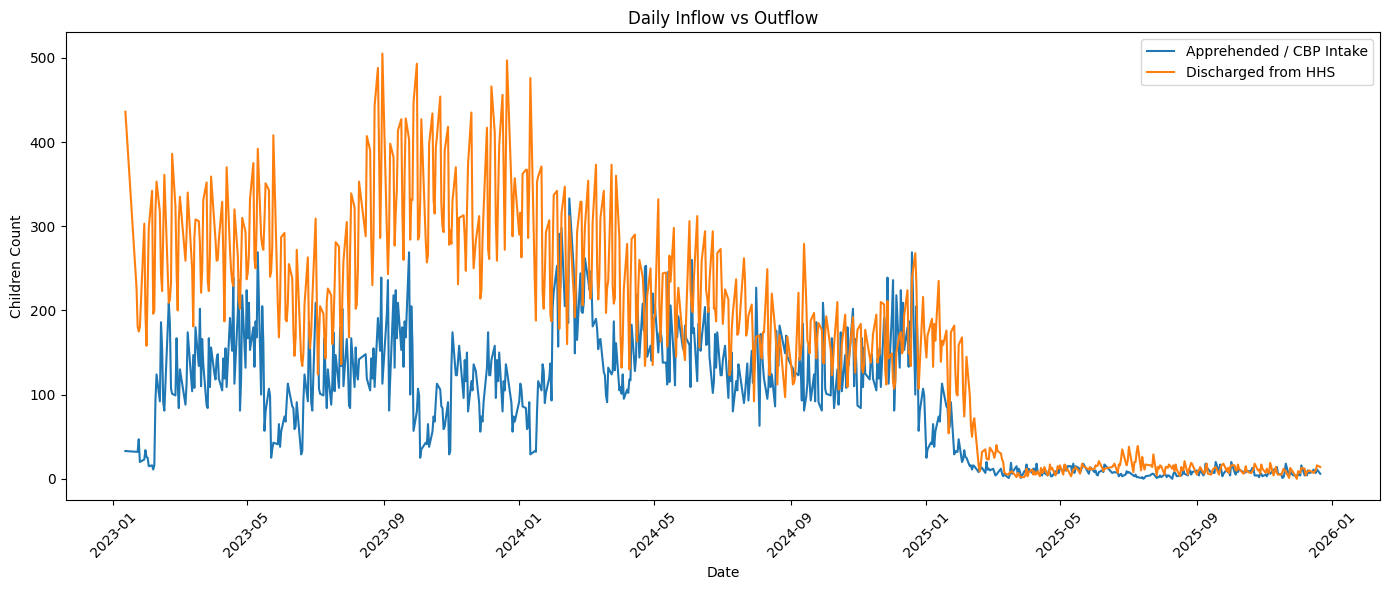

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(df["Date"], df["Children apprehended and placed in CBP custody*"], label="Apprehended / CBP Intake")
plt.plot(df["Date"], df["Children discharged from HHS Care"], label="Discharged from HHS")
plt.title("Daily Inflow vs Outflow")
plt.xlabel("Date")
plt.ylabel("Children Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

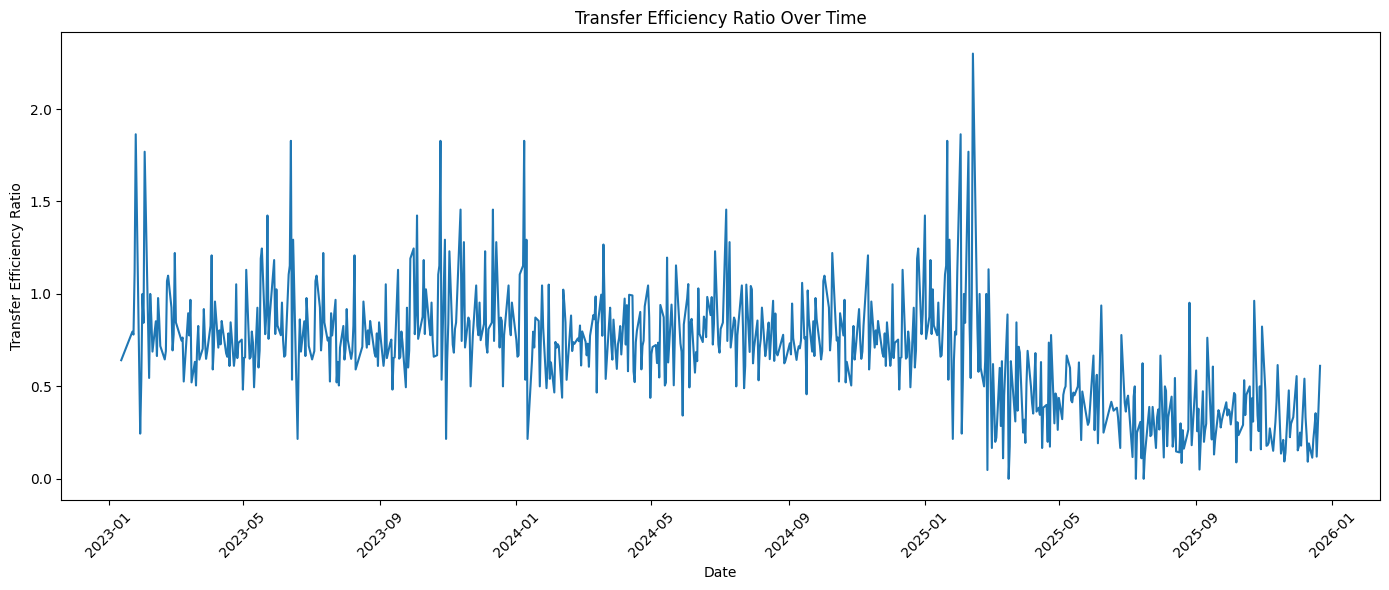

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(df["Date"], df["Transfer Efficiency Ratio"])
plt.title("Transfer Efficiency Ratio Over Time")
plt.xlabel("Date")
plt.ylabel("Transfer Efficiency Ratio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

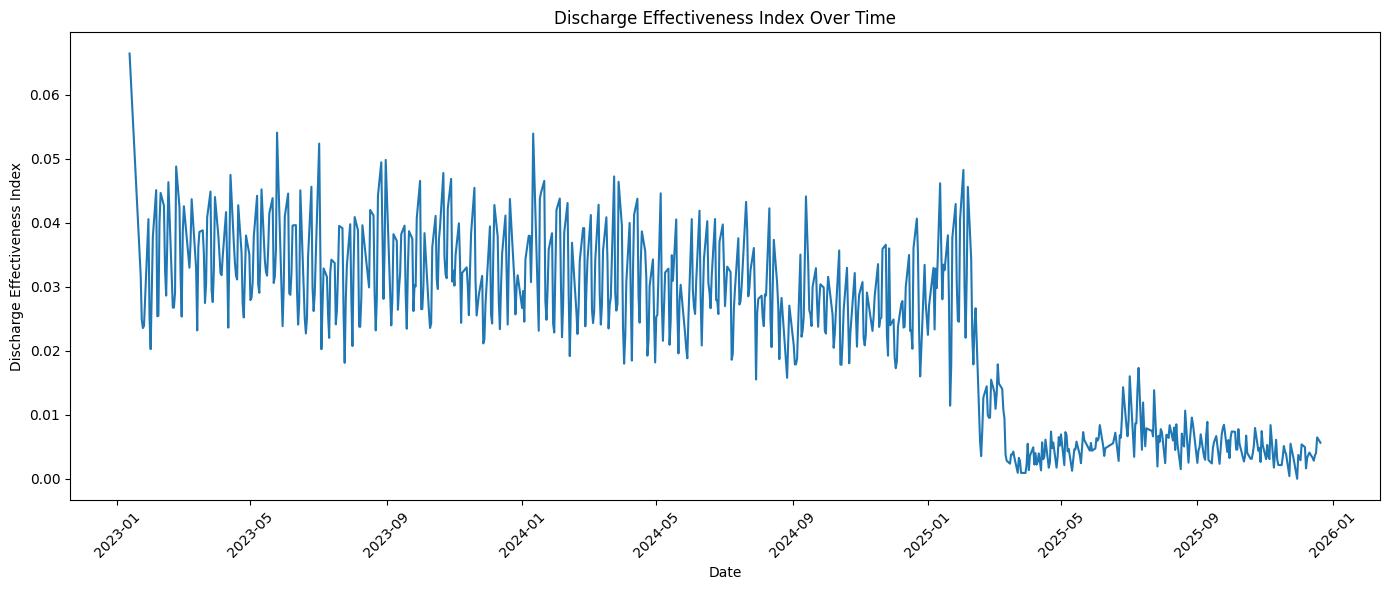

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(df["Date"], df["Discharge Effectiveness Index"])
plt.title("Discharge Effectiveness Index Over Time")
plt.xlabel("Date")
plt.ylabel("Discharge Effectiveness Index")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

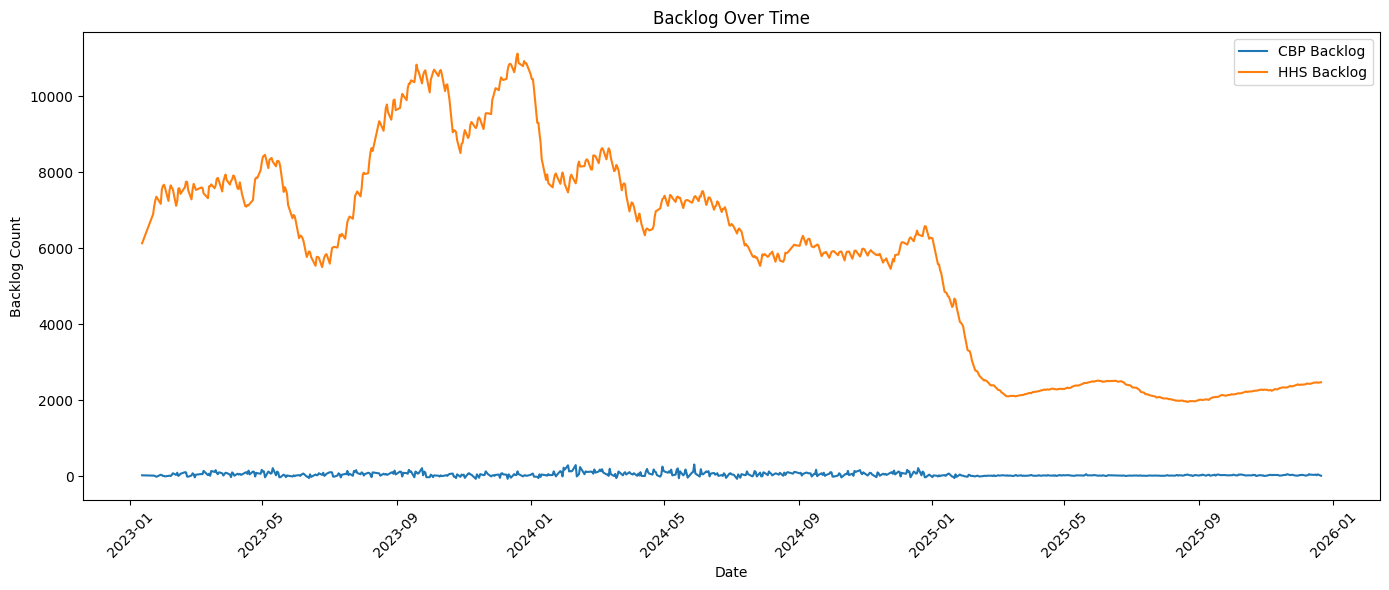

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(df["Date"], df["CBP Backlog"], label="CBP Backlog")
plt.plot(df["Date"], df["HHS Backlog"], label="HHS Backlog")
plt.title("Backlog Over Time")
plt.xlabel("Date")
plt.ylabel("Backlog Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

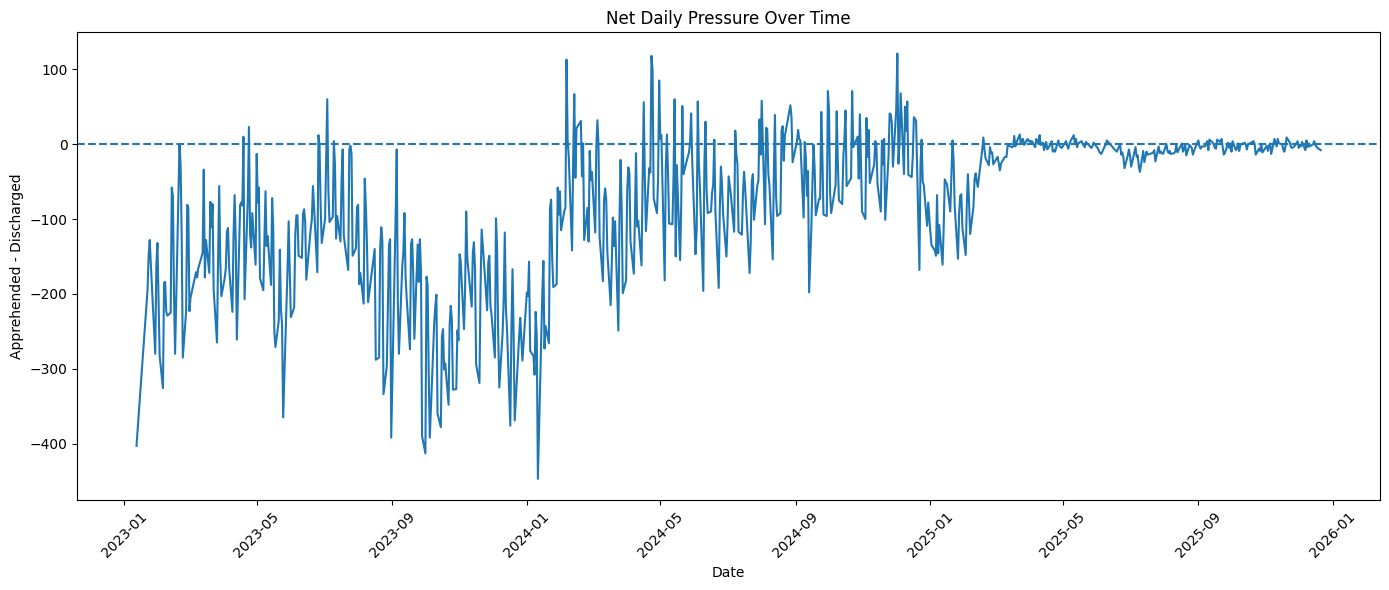

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(df["Date"], df["Net Daily Pressure"])
plt.axhline(0, linestyle="--")
plt.title("Net Daily Pressure Over Time")
plt.xlabel("Date")
plt.ylabel("Apprehended - Discharged")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
weekday_analysis = df.groupby("Day Name")[[
    "Transfer Efficiency Ratio",
    "Discharge Effectiveness Index",
    "Pipeline Throughput Rate",
    "CBP Backlog",
    "HHS Backlog"
]].mean()

weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

weekday_analysis = weekday_analysis.reindex(weekday_order)
weekday_analysis

,Transfer Efficiency Ratio,Discharge Effectiveness Index,Pipeline Throughput Rate,CBP Backlog,HHS Backlog
Day Name,,,,,
Monday,0.660516,0.021711,2.368546,44.213793,5905.958621
Tuesday,0.670485,0.018705,2.021825,48.697987,5946.322148
Wednesday,0.692006,0.022596,2.477646,44.197279,5992.816327
Thursday,0.732629,0.027853,2.997023,37.795918,5923.102041
Friday,0.711818,0.024037,2.284722,1.000000,4152.500000
Saturday,NaN,NaN,NaN,NaN,NaN
Sunday,0.700083,0.028396,2.676871,39.330769,5668.876923


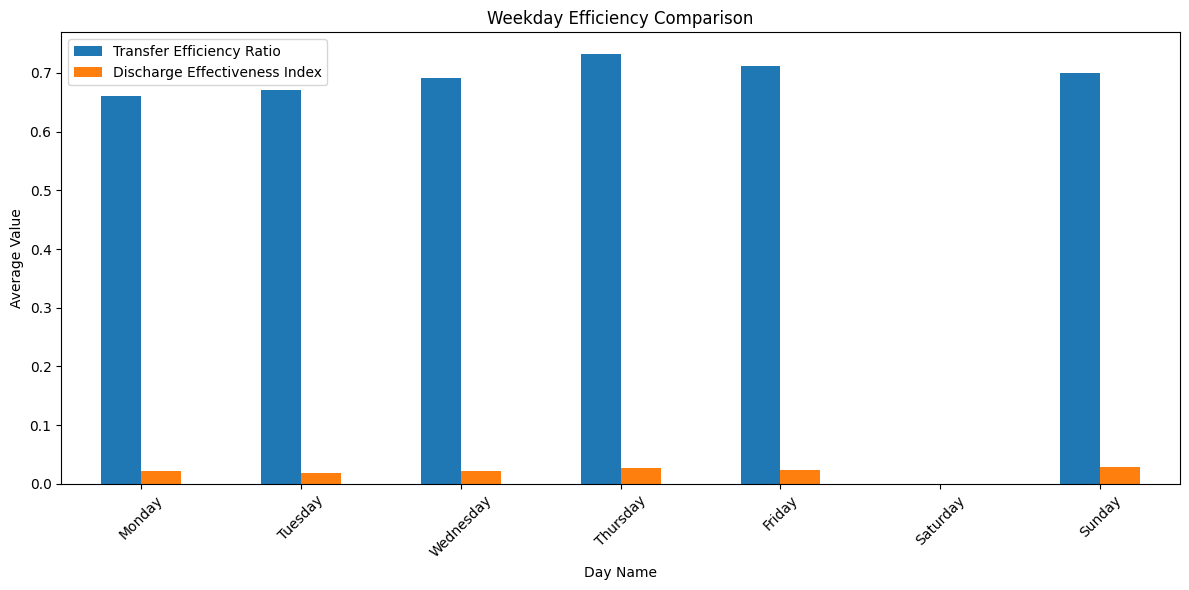

In [ ]:
weekday_analysis[["Transfer Efficiency Ratio", "Discharge Effectiveness Index"]].plot(
    kind="bar",
    figsize=(12,6)
)
plt.title("Weekday Efficiency Comparison")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
monthly_analysis = df.groupby("Month")[[
    "Children apprehended and placed in CBP custody*",
    "Children discharged from HHS Care",
    "Transfer Efficiency Ratio",
    "Discharge Effectiveness Index",
    "CBP Backlog",
    "HHS Backlog",
    "Net Daily Pressure"
]].mean()

monthly_analysis.head(12)

,Children apprehended and placed in CBP custody*,Children discharged from HHS Care,Transfer Efficiency Ratio,Discharge Effectiveness Index,CBP Backlog,HHS Backlog,Net Daily Pressure
Month,,,,,,,
2023-01,30.875000,232.000000,0.872699,0.032084,9.375000,7137.625000,-201.125000
2023-02,99.263158,272.789474,0.869857,0.035032,32.526316,7523.000000,-173.526316
2023-03,130.473684,282.894737,0.752319,0.035613,66.210526,7662.473684,-152.421053
2023-04,149.000000,269.904762,0.774376,0.034435,61.285714,7572.761905,-120.904762
2023-05,124.818182,284.363636,0.847388,0.034681,52.318182,7902.772727,-159.545455
2023-06,88.700000,201.450000,0.851882,0.032703,24.850000,5935.000000,-112.750000
2023-07,136.095238,209.857143,0.785406,0.030792,59.714286,6618.238095,-73.761905
2023-08,137.550000,323.500000,0.774691,0.034399,57.850000,9024.400000,-185.950000
2023-09,168.105263,344.526316,0.744781,0.032164,82.052632,10356.789474,-176.421053


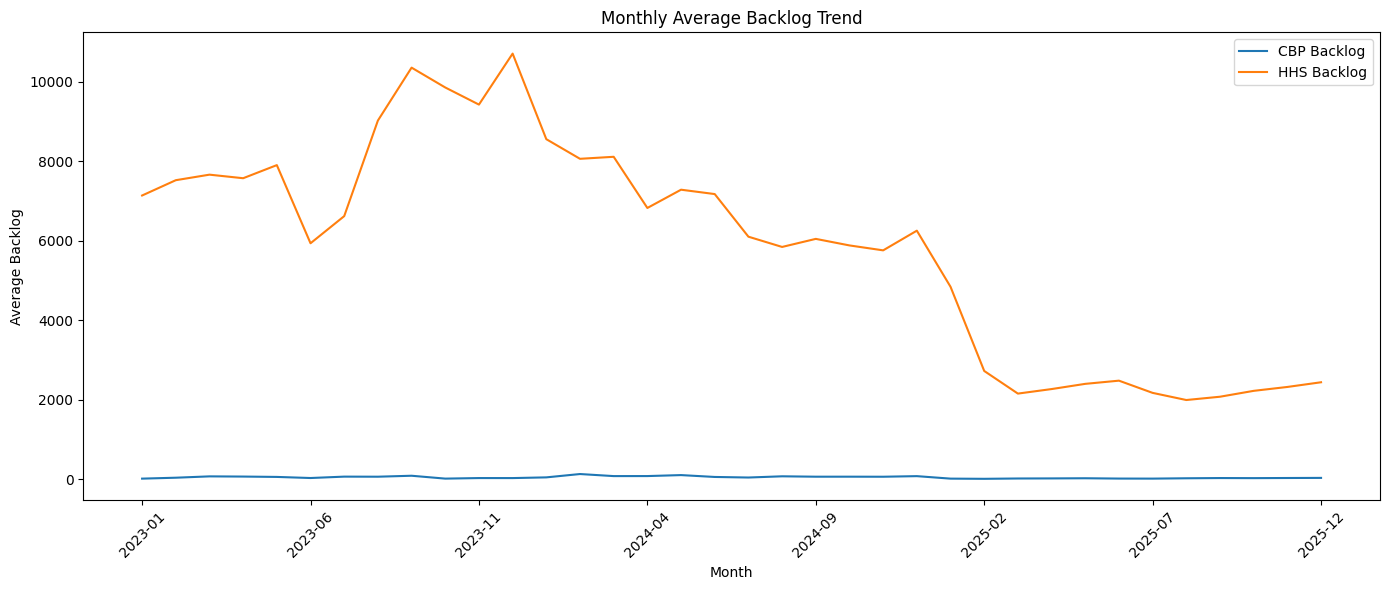

In [ ]:
monthly_analysis[["CBP Backlog", "HHS Backlog"]].plot(figsize=(14,6))
plt.title("Monthly Average Backlog Trend")
plt.xlabel("Month")
plt.ylabel("Average Backlog")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
bottleneck_days = df[
    (df["Transfer Bottleneck Flag"] == 1) |
    (df["Discharge Bottleneck Flag"] == 1)
][[
    "Date",
    "Transfer Efficiency Ratio",
    "Discharge Effectiveness Index",
    "CBP Backlog",
    "HHS Backlog"
]]

bottleneck_days.head(20)

,Date,Transfer Efficiency Ratio,Discharge Effectiveness Index,CBP Backlog,HHS Backlog
5,2023-01-29,0.244444,0.040551,34.0,7169.0
67,2023-05-01,0.482540,0.027909,163.0,8255.0
75,2023-05-11,0.495146,0.045203,208.0,8280.0
100,2023-06-19,0.215686,0.025004,40.0,5537.0
156,2023-09-12,0.482540,0.029674,163.0,10333.0
164,2023-09-24,0.495146,0.037509,208.0,10341.0
189,2023-10-30,0.215686,0.030800,40.0,8748.0
238,2024-01-11,0.215686,0.053913,40.0,8353.0
248,2024-01-28,0.490272,0.038356,131.0,7697.0
253,2024-02-04,0.467043,0.043773,283.0,7471.0


In [ ]:
top_pressure_days = df.sort_values("Net Daily Pressure", ascending=False)[[
    "Date",
    "Children apprehended and placed in CBP custody*",
    "Children discharged from HHS Care",
    "Net Daily Pressure"
]].head(10)

top_pressure_days

,Date,Children apprehended and placed in CBP custody*,Children discharged from HHS Care,Net Daily Pressure
460,2024-12-02,236.0,115.0,121.0
309,2024-04-23,252.0,134.0,118.0
255,2024-02-06,291.0,178.0,113.0
310,2024-04-24,253.0,154.0,99.0
314,2024-04-30,220.0,135.0,85.0
418,2024-09-30,209.0,138.0,71.0
433,2024-10-22,180.0,109.0,71.0
463,2024-12-05,218.0,150.0,68.0
260,2024-02-13,227.0,160.0,67.0
110,2023-07-04,184.0,124.0,60.0


In [ ]:
avg_transfer = df["Transfer Efficiency Ratio"].mean()
avg_discharge = df["Discharge Effectiveness Index"].mean()
avg_throughput = df["Pipeline Throughput Rate"].mean()
avg_cbp_backlog = df["CBP Backlog"].mean()
avg_hhs_backlog = df["HHS Backlog"].mean()

print("PROJECT INSIGHTS\n")

print(f"1. Average Transfer Efficiency Ratio is {avg_transfer:.3f}.")
print(f"2. Average Discharge Effectiveness Index is {avg_discharge:.3f}.")
print(f"3. Average Pipeline Throughput Rate is {avg_throughput:.3f}.")
print(f"4. Average CBP Backlog is {avg_cbp_backlog:.2f}.")
print(f"5. Average HHS Backlog is {avg_hhs_backlog:.2f}.")

if avg_transfer < 0.5:
    print("6. Transfer efficiency appears weak on average, suggesting CBP to HHS movement delays.")
else:
    print("6. Transfer efficiency appears relatively healthy on average.")

if avg_discharge < 0.02:
    print("7. Discharge effectiveness is low, indicating a slow rate of exits relative to HHS active care load.")
else:
    print("7. Discharge effectiveness appears relatively stable.")

PROJECT INSIGHTS

1. Average Transfer Efficiency Ratio is 0.691.
2. Average Discharge Effectiveness Index is 0.024.
3. Average Pipeline Throughput Rate is 2.503.
4. Average CBP Backlog is 42.83.
5. Average HHS Backlog is 5887.87.
6. Transfer efficiency appears relatively healthy on average.
7. Discharge effectiveness appears relatively stable.


In [ ]:
df.to_csv("cleaned_uac_pipeline_analytics.csv", index=False)
print("Saved as cleaned_uac_pipeline_analytics.csv")

Saved as cleaned_uac_pipeline_analytics.csv


In [ ]:
from google.colab import files
files.download("cleaned_uac_pipeline_analytics.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df.to_csv("cleaned_uac_pipeline_analytics.csv", index=False)